In [26]:
import pandas as pd
import numpy as np
from scipy.spatial import Voronoi
from matplotlib import pyplot as plt

### 1. Generation of the particles coordinates on a square grid

In [69]:
# initialising parameters of the bidisperse mixture

# number of particles
nb_big_side = 10
nb_small_side = nb_big_side - 1
nb_big = nb_big_side**2
nb_small = nb_small_side**2

coord = np.zeros([nb_big+nb_small, 4])

# Physical size dimensions
dist_param = 1. # distance parameter to link with physical forces constants

side_size = 1. * dist_param
density_big = 1./(side_size**2)
density_small = 1./(side_size**2)
side_sample = nb_big_side * side_size
surface_sample = side_sample**2

# noise in positions of particles generation
noise_param = 0.05



In [76]:
# Generating coordinates array
idx = 0
np.random.seed(0)

def noise_gen(noise_param = noise_param): # generating quasi normal random noise with max abs noise set to side_size/10.
    noise = 0.
    if noise_param * side_size * np.random.randn() >= 0. :
        noise = np.min([noise_param * side_size * np.random.randn(), side_size/10.])
    else:
        noise = np.max(([noise_param * side_size * np.random.randn(), -side_size/10.]))

    return noise

# for big particles
for j in range(nb_big_side): # columns generation
    
    for i in range(nb_big_side): # rows generation
        pos_x = side_size/2. + i * side_size + noise_gen()
        pos_y = side_size/2. + j * side_size + noise_gen()

        coord[idx, 0] = idx
        coord[idx, 1] = pos_x
        coord[idx, 2] = pos_y
        coord[idx, 3] = 1

        idx += 1

# for small particles
for j in range(nb_small_side): # columns generation

    for i in range(nb_small_side): # rows generation
        pos_x = side_size + i * side_size + noise_gen()
        pos_y = side_size + j * side_size + noise_gen()

        coord[idx, 0] = idx
        coord[idx, 1] = pos_x
        coord[idx, 2] = pos_y
        coord[idx, 3] = 0

        idx += 1


coord[:10]

array([[0.        , 0.52000786, 0.6       , 1.        ],
       [1.        , 1.45113611, 0.49243214, 1.        ],
       [2.        , 2.52052993, 0.57271368, 1.        ],
       [3.        , 3.50608375, 0.51668372, 1.        ],
       [4.        , 4.48974209, 0.45729521, 1.        ],
       [5.        , 5.53268093, 0.46289175, 1.        ],
       [6.        , 6.42728172, 0.49064081, 1.        ],
       [7.        , 7.57346794, 0.51890813, 1.        ],
       [8.        , 8.40096018, 0.50781745, 1.        ],
       [9.        , 9.56011899, 0.48488486, 1.        ]])

In [77]:
coord[-10:]

array([[171.        ,   8.9       ,   7.91945608,   0.        ],
       [172.        ,   1.11903727,   9.04746232,   0.        ],
       [173.        ,   1.91111665,   9.05453749,   0.        ],
       [174.        ,   2.96026818,   9.05409676,   0.        ],
       [175.        ,   3.93947285,   9.05473192,   0.        ],
       [176.        ,   5.1       ,   8.99824524,   0.        ],
       [177.        ,   6.01057485,   9.03399874,   0.        ],
       [178.        ,   6.98548014,   8.99493593,   0.        ],
       [179.        ,   7.97678312,   8.97237297,   0.        ],
       [180.        ,   8.97448536,   8.98072551,   0.        ]])

In [78]:
# voronoi tesselation with scipy
vr = Voronoi(coord[:, [1,2]])

In [79]:
vr.vertices.shape

(350, 2)

In [80]:
vr.vertices[:10,0]

array([5.87780172e+02, 7.00491467e+00, 4.52416721e+01, 2.09870550e+01,
       4.48906028e-01, 9.86125546e-01, 1.68576301e+01, 5.38649266e+00,
       1.97760915e+00, 6.59371261e+00])

(0.0, 10.0)

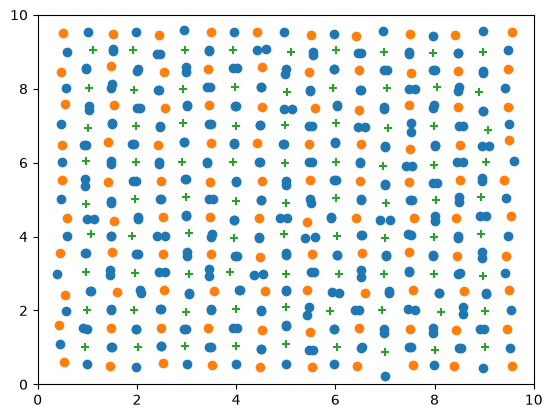

In [89]:
plt.scatter(x=vr.vertices[:, 0], y=vr.vertices[:,1])
plt.scatter(x=coord[:100, 1], y=coord[:100, 2])
plt.scatter(x=coord[100:, 1], y=coord[100:, 2], marker="+")
plt.xlim(0,10)
plt.ylim(0,10)

(array([[ 0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  2.,  0., 56.,
         78., 72., 76., 54.,  0.,  1.,  0.,  1.,  1.,  1.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
          0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0., 50.,
         77., 75., 81., 55.,  0.,  0.,  0.,  0.,  2.,  1.,  1.,  0.,  0.,
          0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]]),
 array([-50., -48., -46., -44., -42., -40., -38., -36., -34., -32., -30.,
        -28., -26., -24., -22., -20., -18., -16., -14., -12., -10.,  -8.,
         -6.,  -4.,  -2.,   0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,
         16.,  18.,  20.,  22.,  24.,  26.,  28.,  30.,  32.,  34.,  36.,
         38.,  40.,  42.,  44.,  46.,  48.,  50.]),
 <a list of 2 BarContainer objects>)

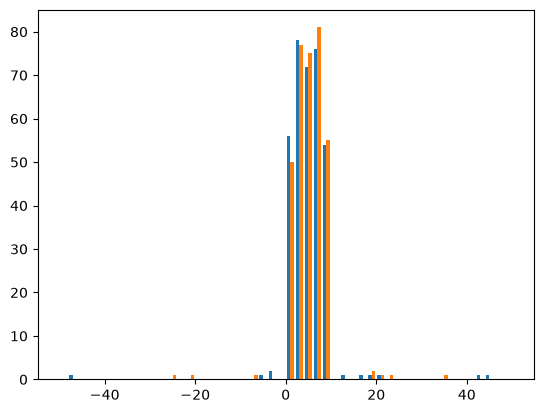

In [88]:
plt.hist(vr.vertices, range= [-50,50], bins=50)